Probelm Statement

Brain Tumor Detection and Classification Using CNN and Deep Learning

Brain tumors are one of the most serious neurological disorders that can affect people of all age groups. Early and accurate detection of brain tumors is essential for effective treatment planning and improving patient survival rates. Traditional diagnosis using MRI scans requires experienced radiologists and can sometimes be time-consuming, expensive, and prone to human error, especially when large numbers of medical images need to be analyzed.

With the advancement of Artificial Intelligence and Deep Learning, automated medical image analysis has become an important research area. Convolutional Neural Networks (CNNs) are highly effective in image classification tasks because they can automatically learn important features from images without manual feature extraction.

The aim of this project is to develop a CNN-based Deep Learning system capable of detecting and classifying brain tumors from MRI images into four categories:

Glioma Tumor
Meningioma Tumor
Pituitary Tumor
No Tumor

The proposed system uses MRI brain scan images as input and applies image preprocessing, feature extraction, and CNN-based classification techniques to identify the tumor type accurately. The model is trained and tested using a labeled image dataset to improve prediction performance and reduce misclassification.

This project helps support medical professionals by providing a faster, automated, and reliable tumor classification system. The developed model can assist in early diagnosis, reduce workload on radiologists, and improve healthcare decision-making using Deep Learning techniques

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [3]:
DATASET_PATH=r"C:\Users\USER\Desktop\fathima\brain_tumour\data image"

In [5]:
#  Image Data Generators
train_datagen= ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.1  # 10% of training data for validation
)

#  Training data
train_generator=train_datagen.flow_from_directory(
    DATASET_PATH + "\\Training",
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

#  Validation data
val_generator=train_datagen.flow_from_directory(
    DATASET_PATH + "\\Training",
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

#  Test data
test_datagen=ImageDataGenerator(rescale=1./255)
test_generator=test_datagen.flow_from_directory(
    DATASET_PATH  + "\\Testing",
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

Found 5143 images belonging to 4 classes.
Found 569 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


In [10]:
#  CNN Model
model=Sequential([
    Conv2D(32, (3,3),activation='relu',input_shape=(150, 150, 3)),
    MaxPooling2D(2,2),
    
    Conv2D(64, (3,3),activation='relu'),
    MaxPooling2D(2,2),
    
    Conv2D(128, (3,3),activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(512, (3,3),activation='relu'),
    MaxPooling2D(2,2),
    
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')  # 4 classes: Glioma, Meningioma, Pituitary, No Tumor
])

#  Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

c:\Users\USER\Desktop\fathima\brain_tumour\brain_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.fit(train_generator,validation_data=val_generator,epochs=30 
          
          )

Epoch 1/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 111s 688ms/step - accuracy: 0.9300 - loss: 0.1886 - val_accuracy: 0.8735 - val_loss: 0.3527
Epoch 2/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 111s 687ms/step - accuracy: 0.9382 - loss: 0.1652 - val_accuracy: 0.8647 - val_loss: 0.4300
Epoch 3/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 111s 689ms/step - accuracy: 0.9421 - loss: 0.1644 - val_accuracy: 0.8928 - val_loss: 0.3608
Epoch 4/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 111s 688ms/step - accuracy: 0.9399 - loss: 0.1614 - val_accuracy: 0.8946 - val_loss: 0.3343
Epoch 5/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 111s 687ms/step - accuracy: 0.9444 - loss: 0.1559 - val_accuracy: 0.9121 - val_loss: 0.3744
Epoch 6/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 106s 660ms/step - accuracy: 0.9471 - loss: 0.1524 - val_accuracy: 0.8963 - val_loss: 0.3359
Epoch 7/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 102s 633ms/step - accuracy: 0.9428 - loss: 0.1539 - val_accuracy: 0.8822 - val_loss: 0.3911
Epoch 8/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 103s 641ms/step - accuracy: 0.9421 -

In [ ]:
# img_path = r"C:\Users\USER\Desktop\fathima\brain_tumour\data image\pitutary_2.jpg"

In [ ]:
# img_path = r"C:\Users\USER\Desktop\fathima\brain_tumour\data image\glioma_exmp.jpg"


In [13]:
img_path=r"C:\Users\USER\Desktop\fathima\brain_tumour\data image\meningloma.jpg"

In [ ]:
# img_path = r"C:\Users\USER\Desktop\fathima\brain_tumour\data image\no_tumer.jpg"


In [14]:
class_labels=["Glioma","Meningloma","No Tumor","Pitutary"]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step

Predicted Class: Meningloma
Confidence: 87.81%


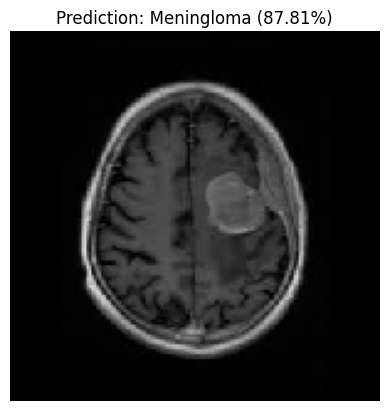

In [15]:
# Load and preprocess image
img=load_img(img_path,target_size=(150, 150))
img_array=img_to_array(img)
img_array=np.expand_dims(img_array,axis=0)
img_array=img_array/255.0

# Predict
prediction = model.predict(img_array)
predicted_index = np.argmax(prediction, axis=1)[0]
predicted_label = class_labels[predicted_index]
confidence = np.max(prediction) * 100

print(f"\nPredicted Class: {predicted_label}")
print(f"Confidence: {confidence:.2f}%")


plt.imshow(img)
plt.title(f"Prediction: {predicted_label} ({confidence:.2f}%)")
plt.axis("off")
plt.show()

Conclusion

The “Brain Tumor Detection and Classification Using CNN and Deep Learning” project was successfully developed to classify MRI brain scan images into four categories: Glioma Tumor, Meningioma Tumor, Pituitary Tumor, and No Tumor. The system uses Convolutional Neural Networks (CNN) to automatically learn important image features and perform accurate tumor classification without manual feature extraction.

Image preprocessing and augmentation techniques such as rescaling, rotation, zooming, shifting, shearing, and horizontal flipping were applied using ImageDataGenerator to improve model generalization and reduce overfitting. The CNN architecture consisted of multiple convolutional, max-pooling, dense, and dropout layers, enabling the model to effectively extract spatial features from MRI images.

The model was trained using labeled MRI datasets and achieved an accuracy of approximately 96.75%, demonstrating strong performance in detecting and classifying brain tumors. The high accuracy indicates that CNN-based deep learning models can provide reliable and efficient support for automated medical image analysis.

This project shows that Deep Learning can play an important role in assisting healthcare professionals by enabling faster diagnosis, reducing manual effort, and improving decision-making in medical imaging. The developed system can help radiologists identify brain tumors more efficiently and may contribute to early diagnosis and better patient treatment outcomes.

In future work, the model can be further improved by using larger datasets, transfer learning techniques, advanced CNN architectures, and real-time deployment through web or mobile healthcare applications.